# Microhaplotypes and Mixture Analysis

Asdf.

In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt
import microhapulator
import numpy
import pandas
import seaborn

matplotlib.rcParams['axes.labelsize'] = 16
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['savefig.dpi'] = 300
seaborn.set_context({"figure.figsize": (12, 8)})

## Data Import and Inspection

In [2]:
contain = pandas.read_csv('sample-containment-eval.tsv', sep='\t')

In [3]:
contain.head()

,ID,Sample,Containment,Proportion
0,00obT9Q,WUgiHEX,0.6988,0.050
1,04CZSJC,6FJPrhq,1.0000,0.790
2,04MfwXR,C49pQVF,1.0000,0.140
3,095R8QJ,nH166DW,1.0000,0.167
4,0BMZNwH,L8FMkV0,0.9059,0.070


## Evaluation of Sample Containment

In [4]:
contribs = contain[contain.Proportion > 0.0]
noncontribs = contain[contain.Proportion == 0.0]

In [5]:
thresh = None
for cand_thresh in (0.07, 0.08, 0.09, 0.1, 0.11):
    test = contribs[contribs.Proportion > cand_thresh]
    perc_perfect_containment = len(test[test.Containment == 1.0]) / len(test)
    print(cand_thresh, round(perc_perfect_containment, 4))
    if thresh is None and perc_perfect_containment > 0.95:
        thresh = cand_thresh

0.07 0.9484
0.08 0.9584
0.09 0.9713
0.1 0.9779
0.11 0.9838


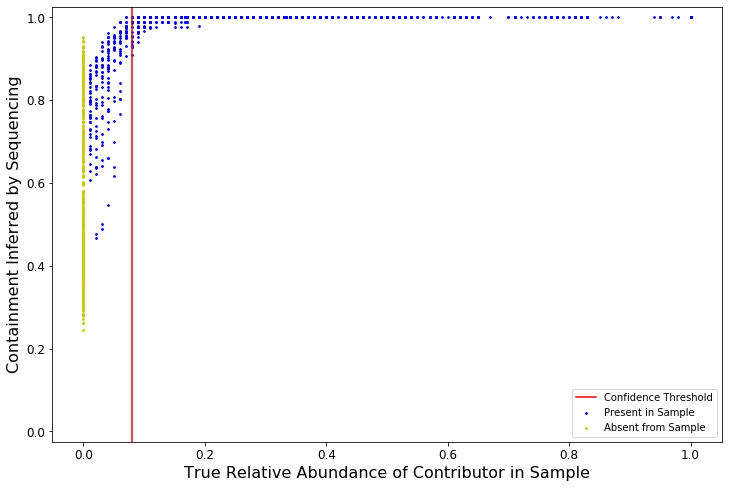

In [6]:
seaborn.set_context({"figure.figsize": (12, 8)})
_ = plt.scatter(contribs.Proportion, contribs.Containment, color='blue', s=3, label='Present in Sample')
_ = plt.scatter(noncontribs.Proportion, noncontribs.Containment, color='#cccc00', s=3, label='Absent from Sample')
_ = plt.axvline(x=thresh, color='red', label='Confidence Threshold')
_ = plt.xlabel('True Relative Abundance of Contributor in Sample')
_ = plt.ylabel('Containment Inferred by Sequencing')
_ = plt.ylim(-0.025, 1.025)
_ = plt.legend(loc='lower right')
_ = plt.savefig('containment.pdf')
_ = plt.show()